In [1]:
import anndata as ad 
import squidpy as sq 
import scanpy as sc 
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import muon as mu

/opt/conda/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import sys 
sys.path.insert(0, './nschmidt/project/GNNfinalproject/src/utils/')
from data_loading import cell_type_split_dataset, uniform_split_dataset

In [3]:
bmmc = ad.read_h5ad('./nschmidt/project/GNNfinalproject/data/bmmc_70k_multiome.h5ad')

bmmc.obs_names_make_unique

<bound method AnnData.obs_names_make_unique of AnnData object with n_obs × n_vars = 69249 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'>

In [33]:
bmmc.var

,feature_types,gene_id
AL627309.5,GEX,ENSG00000241860
LINC01409,GEX,ENSG00000237491
LINC01128,GEX,ENSG00000228794
NOC2L,GEX,ENSG00000188976
KLHL17,GEX,ENSG00000187961
...,...,...
GL000219.1-90062-90937,ATAC,NaN
GL000219.1-99257-100160,ATAC,NaN
KI270726.1-27152-28034,ATAC,NaN
KI270713.1-21434-22336,ATAC,NaN


In [34]:
rna_bmmc = bmmc[:, bmmc.var['feature_types'] == 'GEX']
rna_bmmc

View of AnnData object with n_obs × n_vars = 69249 × 13431
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [35]:
rna_bmmc.var['mt'] = rna_bmmc.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(rna_bmmc, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

/tmp/ipykernel_4638/3164062108.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  rna_bmmc.var['mt'] = rna_bmmc.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'


/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


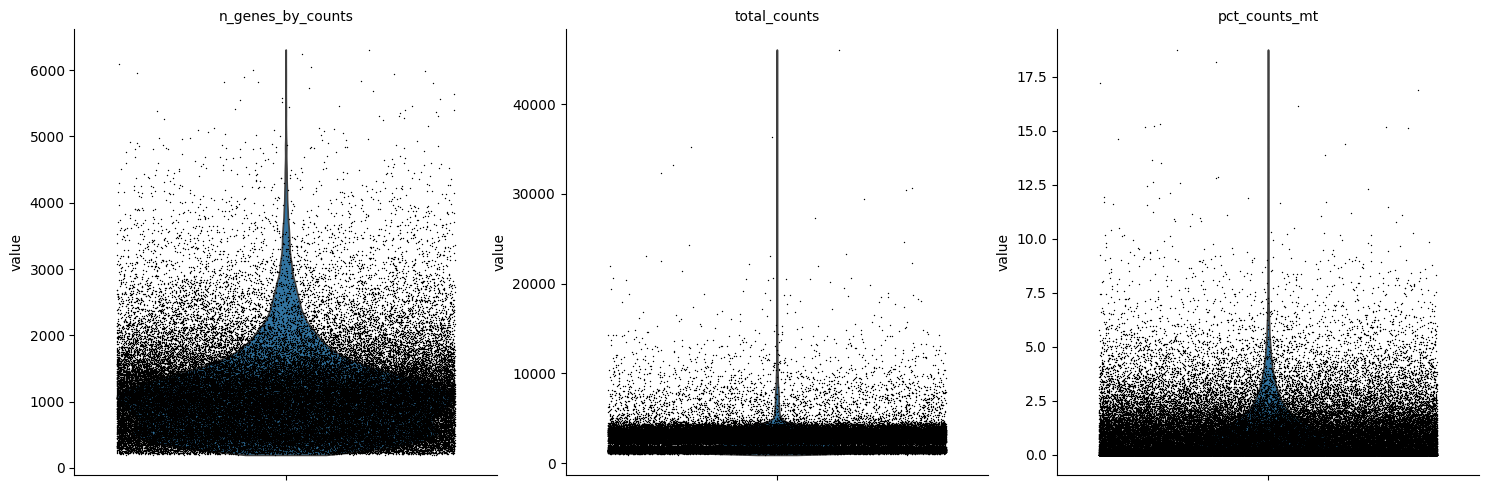

In [36]:
sc.pl.violin(rna_bmmc, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [37]:
rna_bmmc

AnnData object with n_obs × n_vars = 69249 × 13431
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature_types', 'gene_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [39]:
mu.pp.filter_var(rna_bmmc, 'n_cells_by_counts', lambda x: x >= 3)

mu.pp.filter_obs(rna_bmmc, 'n_genes_by_counts', lambda x: (x >= 200) & (x < 4000))

mu.pp.filter_obs(rna_bmmc, 'total_counts', lambda x: x < 15000)
mu.pp.filter_obs(rna_bmmc, 'pct_counts_mt', lambda x: x < 20)

rna_bmmc

AnnData object with n_obs × n_vars = 68867 × 13431
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature_types', 'gene_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


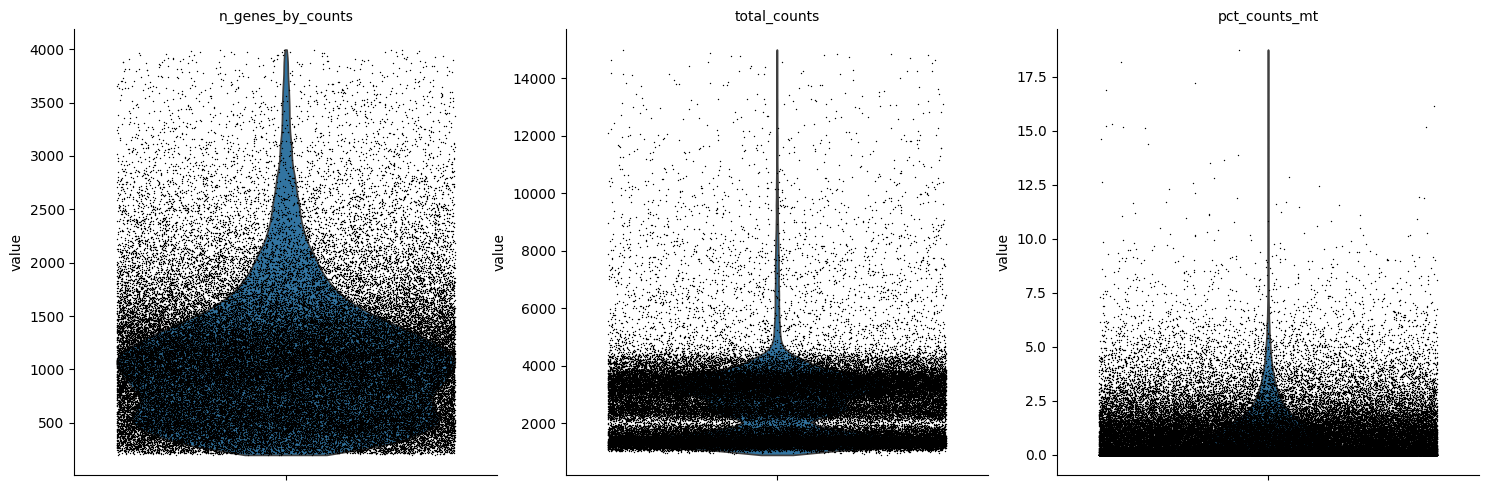

In [40]:
sc.pl.violin(rna_bmmc, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [123]:
train_idx, val_idx, test_idx = uniform_split_dataset(rna_bmmc, test_ratio=0.1, val_ratio=0.2, seed=19193)

In [45]:
train_rna = rna_bmmc[train_idx, :]
# library normalization
sc.pp.normalize_total(train_rna, target_sum=1e4)

# log transform
sc.pp.log1p(train_rna)

train_rna.X.min()

/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:216: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


0.0

In [46]:
train_rna

AnnData object with n_obs × n_vars = 48226 × 13431
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature_types', 'gene_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'log1p'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [61]:
# select variable genes
sc.pp.highly_variable_genes(train_rna, n_top_genes=10000)
train_rna = train_rna[:, train_rna.var.highly_variable]
train_rna

/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:698: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


View of AnnData object with n_obs × n_vars = 48226 × 2000
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature_types', 'gene_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'log1p', 'hvg'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [62]:
train_rna.var_names

Index(['GPR153', 'ESPN', 'PER3', 'TNFRSF9', 'AL109811.2', 'AL021155.5', 'KAZN',
       'DNAJC16', 'PADI4', 'NBPF3',
       ...
       'MT-CO1', 'MT-ATP8', 'MT-ATP6', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5',
       'MT-ND6', 'AL592183.1', 'AC240274.1'],
      dtype='object', length=2000)

In [63]:
val_rna = rna_bmmc[val_idx, :]
# library normalization
sc.pp.normalize_total(val_rna, target_sum=1e4)

# log transform
sc.pp.log1p(val_rna)

val_rna = val_rna[:, train_rna.var_names]
val_rna

/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:216: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


View of AnnData object with n_obs × n_vars = 13765 × 2000
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature_types', 'gene_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'log1p'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [64]:
test_rna = rna_bmmc[test_idx, :]
# library normalization
sc.pp.normalize_total(test_rna, target_sum=1e4)

# log transform
sc.pp.log1p(test_rna)

# select variable genes
test_rna = test_rna[:, train_rna.var_names]

test_rna


View of AnnData object with n_obs × n_vars = 6876 × 2000
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature_types', 'gene_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'log1p'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [108]:
atac_bmmc = bmmc[:, bmmc.var['feature_types'] == 'ATAC']
atac_bmmc

View of AnnData object with n_obs × n_vars = 69249 × 116490
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_qc.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics
/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


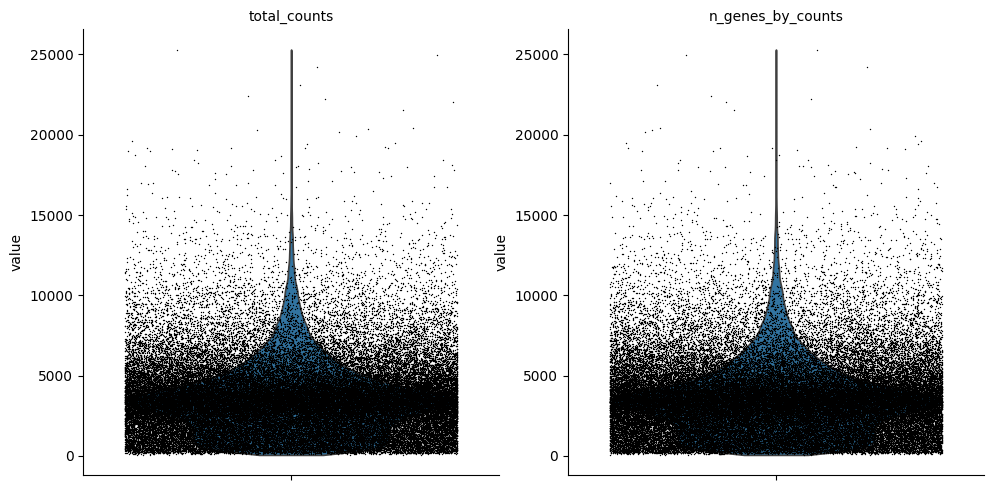

In [109]:
sc.pp.calculate_qc_metrics(atac_bmmc, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(atac_bmmc, ['total_counts', 'n_genes_by_counts'], jitter=0.4, multi_panel=True)

In [114]:
mu.pp.filter_var(atac_bmmc, 'n_cells_by_counts', lambda x: x >= 6000)
mu.pp.filter_obs(atac_bmmc, 'n_genes_by_counts', lambda x: (x >= 100) & (x <= 12000))

mu.pp.filter_obs(atac_bmmc, 'total_counts', lambda x: (x >= 100) & (x <= 15000))

In [115]:
atac_bmmc

AnnData object with n_obs × n_vars = 68701 × 10522
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'n_genes_by_counts', 'total_counts'
    var: 'feature_types', 'gene_id', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


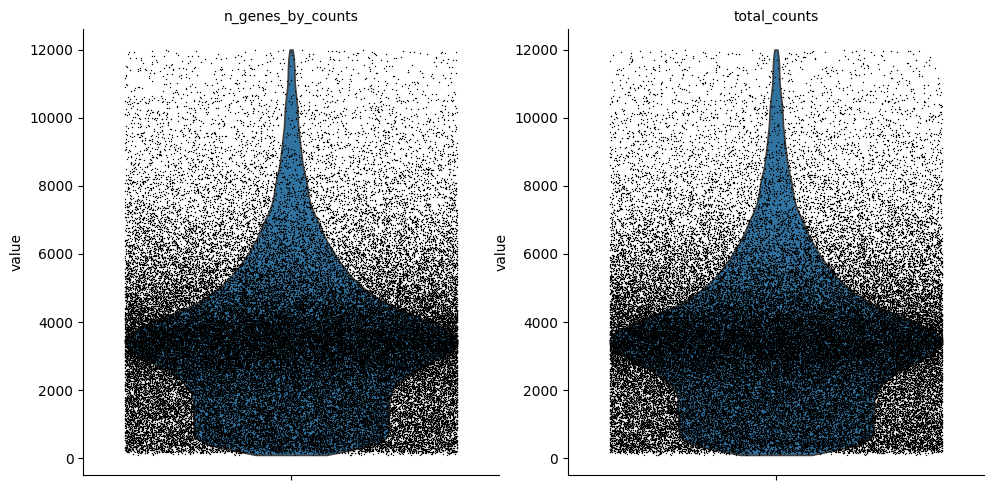

In [116]:
sc.pl.violin(atac_bmmc, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)

In [117]:
atac_bmmc

AnnData object with n_obs × n_vars = 68701 × 10522
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'n_genes_by_counts', 'total_counts'
    var: 'feature_types', 'gene_id', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [118]:
mu.atac.pp.binarize(atac_bmmc)

In [134]:
train_idx, val_idx, test_idx = uniform_split_dataset(atac_bmmc, test_ratio=0.1, val_ratio=0.2, seed=19193)

In [135]:
train_atac = atac_bmmc[train_idx, :]
val_atac = atac_bmmc[val_idx, :]
test_atac = atac_bmmc[test_idx, :]

In [ ]:
train_common_cells = train_rna.obs_names.intersection(train_atac.obs_names)
train_rna = train_rna[train_common_cells].copy()
train_atac = train_atac[train_common_cells].copy()
train_atac = train_atac[sorted(train_atac.obs_names), :]
train_atac = train_atac[ :, sorted(train_atac.var_names),]
train_rna = train_rna[sorted(train_rna.obs_names), :]
train_rna = train_rna[ :, sorted(train_rna.var_names),]

In [138]:
val_common_cells = val_rna.obs_names.intersection(val_atac.obs_names)
val_rna = val_rna[val_common_cells].copy()
val_atac = val_atac[val_common_cells].copy()
val_atac = val_atac[sorted(val_atac.obs_names), :]
val_atac = val_atac[ :, sorted(val_atac.var_names),]
val_rna = val_rna[sorted(val_rna.obs_names), :]
val_rna = val_rna[ :, sorted(val_rna.var_names),]

In [139]:
test_common_cells = test_rna.obs_names.intersection(test_atac.obs_names)
test_rna = test_rna[test_common_cells].copy()
test_atac = test_atac[test_common_cells].copy()
test_atac = test_atac[sorted(test_atac.obs_names), :]
test_atac = test_atac[ :, sorted(test_atac.var_names),]
test_rna = test_rna[sorted(test_rna.obs_names), :]
test_rna = test_rna[ :, sorted(test_rna.var_names),]


In [140]:
train_rna.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc/train_rna.h5ad')
val_rna.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc/val_rna.h5ad')
test_rna.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc/test_rna.h5ad')

train_atac.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc/train_atac.h5ad')
val_atac.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc/val_atac.h5ad')
test_atac.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc/test_atac.h5ad')

## Cell type split

In [4]:
rna_bmmc = bmmc[:, bmmc.var['feature_types'] == 'GEX']
rna_bmmc.var['mt'] = rna_bmmc.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(rna_bmmc, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

atac_bmmc = bmmc[:, bmmc.var['feature_types'] == 'ATAC']

sc.pp.calculate_qc_metrics(atac_bmmc, percent_top=None, log1p=False, inplace=True)


/tmp/ipykernel_5276/2840472209.py:2: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  rna_bmmc.var['mt'] = rna_bmmc.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_qc.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


In [5]:
bmmc.obs["rna_n_genes_by_counts"] = rna_bmmc.obs['n_genes_by_counts']
bmmc.obs["rna_total_counts"] = rna_bmmc.obs['total_counts']
bmmc.obs["rna_pct_counts_mt"] = rna_bmmc.obs['pct_counts_mt']

bmmc.obs["atac_n_genes_by_counts"] = atac_bmmc.obs['n_genes_by_counts']
bmmc.obs["atac_total_counts"] = atac_bmmc.obs['total_counts']


In [6]:
mu.pp.filter_obs(bmmc, 'rna_n_genes_by_counts', lambda x: (x >= 200) & (x < 4000))

mu.pp.filter_obs(bmmc, 'rna_total_counts', lambda x: x < 15000)
mu.pp.filter_obs(bmmc, 'rna_pct_counts_mt', lambda x: x < 20)


mu.pp.filter_obs(bmmc, 'atac_n_genes_by_counts', lambda x: (x >= 100) & (x <= 12000))

mu.pp.filter_obs(bmmc, 'atac_total_counts', lambda x: (x >= 100) & (x <= 15000))



In [8]:
bmmc

AnnData object with n_obs × n_vars = 68388 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'rna_n_genes_by_counts', 'rna_total_counts', 'rna_pct_counts_mt', 'atac_n_genes_by_counts', 'atac_total_counts'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [9]:
rna_bmmc = bmmc[:, bmmc.var['feature_types'] == 'GEX']
rna_bmmc.var['mt'] = rna_bmmc.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(rna_bmmc, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
mu.pp.filter_var(rna_bmmc, 'n_cells_by_counts', lambda x: x >= 3)


atac_bmmc = bmmc[:, bmmc.var['feature_types'] == 'ATAC']
sc.pp.calculate_qc_metrics(atac_bmmc, percent_top=None, log1p=False, inplace=True)
mu.pp.filter_var(atac_bmmc, 'n_cells_by_counts', lambda x: x >= 6000)


/tmp/ipykernel_5276/3981219998.py:2: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  rna_bmmc.var['mt'] = rna_bmmc.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_qc.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


In [10]:
rna_bmmc

AnnData object with n_obs × n_vars = 68388 × 13431
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'rna_n_genes_by_counts', 'rna_total_counts', 'rna_pct_counts_mt', 'atac_n_genes_by_counts', 'atac_total_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature_types', 'gene_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_

In [11]:
atac_bmmc

AnnData object with n_obs × n_vars = 68388 × 10249
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'rna_n_genes_by_counts', 'rna_total_counts', 'rna_pct_counts_mt', 'atac_n_genes_by_counts', 'atac_total_counts', 'n_genes_by_counts', 'total_counts'
    var: 'feature_types', 'gene_id', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [12]:
train_idx, val_idx, test_idx = cell_type_split_dataset(bmmc, annot=True, cell_col='cell_type', cluster_col='leiden', test_ratio=0.1, val_ratio=0.2, seed=19193)

In [13]:
train_rna = rna_bmmc[train_idx, :]
# library normalization
sc.pp.normalize_total(train_rna, target_sum=1e4)

# log transform
sc.pp.log1p(train_rna)

train_rna.X.min()

# select variable genes
sc.pp.highly_variable_genes(train_rna, n_top_genes=10000)
train_rna = train_rna[:, train_rna.var.highly_variable]

val_rna = rna_bmmc[val_idx, :]
# library normalization
sc.pp.normalize_total(val_rna, target_sum=1e4)

# log transform
sc.pp.log1p(val_rna)

val_rna = val_rna[:, train_rna.var_names]

test_rna = rna_bmmc[test_idx, :]
# library normalization
sc.pp.normalize_total(test_rna, target_sum=1e4)

# log transform
sc.pp.log1p(test_rna)

# select variable genes
test_rna = test_rna[:, train_rna.var_names]



/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:216: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:216: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [18]:
train_rna.obs['cell_type'].unique(), test_rna.obs['cell_type'].unique(), val_rna.obs['cell_type'].unique()

(['Naive CD20+ B', 'CD14+ Mono', 'CD8+ T', 'CD16+ Mono', 'CD4+ T naive', ..., 'HSC', 'pDC', 'Proerythroblast', 'Plasma cell', 'cDC2']
 Length: 16
 Categories (16, object): ['CD4+ T activated', 'CD4+ T naive', 'CD8+ T', 'CD14+ Mono', ..., 'Plasma cell', 'Proerythroblast', 'cDC2', 'pDC'],
 ['Lymph prog', 'NK']
 Categories (2, object): ['Lymph prog', 'NK'],
 ['B1 B', 'Transitional B', 'ID2-hi myeloid prog', 'CD8+ T naive']
 Categories (4, object): ['B1 B', 'CD8+ T naive', 'ID2-hi myeloid prog', 'Transitional B'])

In [19]:
mu.atac.pp.binarize(atac_bmmc)

In [20]:
train_atac = atac_bmmc[train_idx, :]
val_atac = atac_bmmc[val_idx, :]
test_atac = atac_bmmc[test_idx, :]

In [22]:
train_atac.obs['cell_type'].unique(), test_atac.obs['cell_type'].unique(), val_atac.obs['cell_type'].unique()

(['Naive CD20+ B', 'CD14+ Mono', 'CD8+ T', 'CD16+ Mono', 'CD4+ T naive', ..., 'HSC', 'pDC', 'Proerythroblast', 'Plasma cell', 'cDC2']
 Length: 16
 Categories (16, object): ['CD4+ T activated', 'CD4+ T naive', 'CD8+ T', 'CD14+ Mono', ..., 'Plasma cell', 'Proerythroblast', 'cDC2', 'pDC'],
 ['Lymph prog', 'NK']
 Categories (2, object): ['Lymph prog', 'NK'],
 ['B1 B', 'Transitional B', 'ID2-hi myeloid prog', 'CD8+ T naive']
 Categories (4, object): ['B1 B', 'CD8+ T naive', 'ID2-hi myeloid prog', 'Transitional B'])

In [21]:
train_rna.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc_celltype_split/train_rna.h5ad')
val_rna.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc_celltype_split/val_rna.h5ad')
test_rna.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc_celltype_split/test_rna.h5ad')

train_atac.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc_celltype_split/train_atac.h5ad')
val_atac.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc_celltype_split/val_atac.h5ad')
test_atac.write('./nschmidt/project/GNNfinalproject/data/preprocessed_data/bmmc_celltype_split/test_atac.h5ad')